# Hyperparamètres — LSTM
Recherche bayésienne via Optuna sur 1 et 2 couches LSTM.
Paramètres explorés : `hidden_size`, `dropout`, `learning_rate`.

In [1]:
print("hello")

hello


In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import torch
import torch.nn as nn

from LSTM import LSTM, make_loaders, evaluate, train_model, set_seed
from settings import (
    DATA_DIR, MODEL_DIR, OUTPUT_DIR,
    PAIRS, N_TARGETS, TARGET_COLS,
    CONTEXT_LENGTH, BATCH_SIZE,
    EPOCHS, EARLY_STOPPING_PATIENCE,
    N_TRIALS, N_EPOCHS_OPTUNA, SEED, DEBUG,
)

if DEBUG:
    EPOCHS          = 3
    N_EPOCHS_OPTUNA = 3
    N_TRIALS        = 2
    print('[DEBUG] Mode debug : epochs=3, trials=2, données=1%')

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}  |  Seed : {SEED}')

Device : cpu  |  Seed : 42


## 1. Chargement des données

In [12]:
splits = {}
for name in ('train', 'validation', 'test'):
    path = DATA_DIR / f'{name}_features_crypto.parquet'
    try:
        splits[name] = pd.read_parquet(path).ffill()
        print(f'{name:12s} {splits[name].shape}  {path.name}')
    except FileNotFoundError:
        print(f'[MANQUANT] {path}')

if len(splits) < 3:
    raise FileNotFoundError(f'Données incomplètes — placez les parquets dans {DATA_DIR}')

if DEBUG:
    splits = {k: v.iloc[:max(int(len(v) * 0.01), CONTEXT_LENGTH + 1)] for k, v in splits.items()}
    print(f'\n[DEBUG] Données réduites à 1% : { {k: v.shape for k, v in splits.items()} }')

train        (171316, 75)  train_features_crypto.parquet
validation   (36710, 75)  validation_features_crypto.parquet
test         (36712, 75)  test_features_crypto.parquet


In [13]:
train_df, val_df, test_df = splits['train'], splits['validation'], splits['test']
feature_cols = [c for c in train_df.columns if c not in TARGET_COLS]

print(f'Features : {len(feature_cols)}  |  Cibles : {TARGET_COLS}')
train_df[TARGET_COLS].describe().round(4)

Features : 73  |  Cibles : ['BTCUSDT_vol_cible_bps', 'ETHUSDT_vol_cible_bps']


,BTCUSDT_vol_cible_bps,ETHUSDT_vol_cible_bps
count,171316.0000,171316.0000
mean,13.0237,16.3374
std,9.4924,11.2765
min,1.4130,1.4900
25%,7.5355,9.8592
50%,10.6756,13.6529
75%,15.3358,19.2813
max,202.6946,253.4925


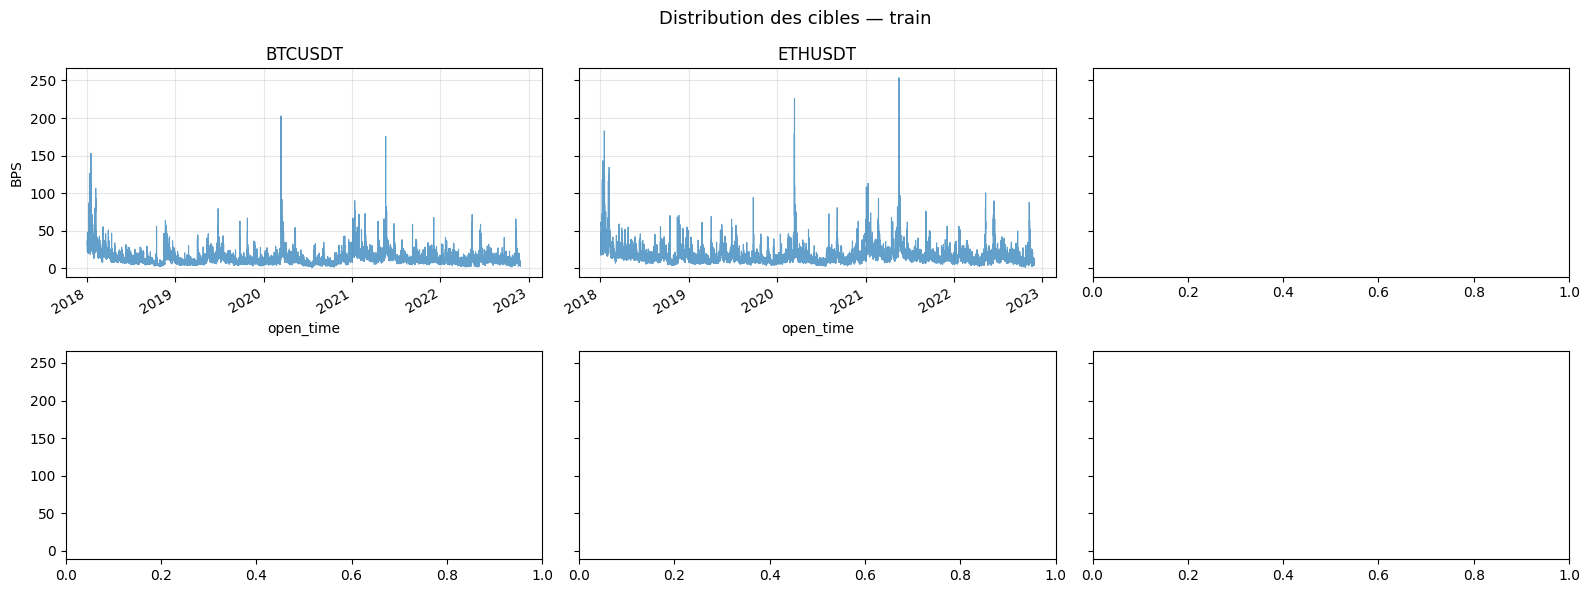

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 6), sharey=True)
fig.suptitle('Distribution des cibles — train', fontsize=13)
for ax, col in zip(axes.flat, TARGET_COLS):
    train_df[col].plot(ax=ax, alpha=0.7, lw=0.8)
    ax.set_title(col.replace('_vol_cible_bps', ''))
    ax.set_ylabel('BPS')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
train_loader, val_loader, test_loader, n_features = make_loaders(
    train_df, val_df, test_df, feature_cols, TARGET_COLS,
    seq_len=CONTEXT_LENGTH, batch_size=BATCH_SIZE, seed=SEED,
)
print(f'n_features={n_features}  |  séquences train={len(train_loader.dataset):,}')

n_features=73  |  séquences train=171,065


## 2. Recherche d'hyperparamètres (Optuna)

In [16]:
def make_objective(num_layers: int):
    def objective(trial):
        hidden_size = trial.suggest_categorical('hidden_size', [64, 128, 256])
        dropout     = trial.suggest_float('dropout', 0.1, 0.5)
        lr          = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

        model = LSTM(
            n_features=n_features, n_targets=N_TARGETS,
            hidden_size=hidden_size, num_layers=num_layers,
            dropout_mlp=dropout,
        ).to(device)

        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        best_val = float('inf')

        for epoch in range(1, N_EPOCHS_OPTUNA + 1):
            model.train()
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                criterion(model(x), y).backward()
                optimizer.step()

            val_rmse = evaluate(model, val_loader, device)
            if val_rmse < best_val:
                best_val = val_rmse
            trial.report(val_rmse, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val
    return objective

In [17]:
STUDY_STORAGE = f"sqlite:///{OUTPUT_DIR}/optuna.db"

studies = {}
for n_layers in (1,):
    study_name = f"lstm_{n_layers}l"
    print(f'\n=== Etude "{study_name}" — {N_TRIALS} essais ===')
    study = optuna.create_study(
        study_name=study_name,
        storage=STUDY_STORAGE,
        load_if_exists=True,
        direction='minimize',
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    n_done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    n_remaining = max(0, N_TRIALS - n_done)
    print(f'  Trials complétés : {n_done}/{N_TRIALS}  →  {n_remaining} restants')
    if n_remaining > 0:
        study.optimize(make_objective(n_layers), n_trials=n_remaining, show_progress_bar=True)
    studies[n_layers] = study
    print(f'Meilleurs params : {study.best_params}  (val RMSE={study.best_value:.4f})')

[I 2026-04-24 12:18:29,004] Using an existing study with name 'lstm_1l' instead of creating a new one.



=== Etude "lstm_1l" — 50 essais ===
  Trials complétés : 0/50  →  50 restants


  0%|          | 0/50 [01:00<?, ?it/s]

[W 2026-04-24 12:19:29,323] Trial 2 failed with parameters: {'hidden_size': 128, 'dropout': 0.3394633936788146, 'lr': 0.0002051338263087451} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/samuel/Documents/code/PSC/Lusis/env/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_17303/395899884.py", line 22, in objective
    criterion(model(x), y).backward()
  File "/home/samuel/Documents/code/PSC/Lusis/env/lib/python3.12/site-packages/torch/_tensor.py", line 630, in backward
    torch.autograd.backward(
  File "/home/samuel/Documents/code/PSC/Lusis/env/lib/python3.12/site-packages/torch/autograd/__init__.py", line 364, in backward
    _engine_run_backward(
  File "/home/samuel/Documents/code/PSC/Lusis/env/lib/python3.12/site-packages/torch/autograd/graph.py", line 865, in _engine_run_backward
    return Variable._exe

KeyboardInterrupt: 

## 3. Ré-entraînement final avec les meilleurs paramètres

In [ ]:
import json

results = {}
for n_layers, study in studies.items():
    bp = study.best_params
    print(f'\n--- Modèle {n_layers} couche(s) | {bp} ---')
    set_seed(SEED)

    model = LSTM(
        n_features=n_features, n_targets=N_TARGETS,
        hidden_size=bp['hidden_size'], num_layers=n_layers,
        dropout_mlp=bp['dropout'],
    )
    model_path = MODEL_DIR / f'lstm_{n_layers}l.pt'

    train_model(
        model, train_loader, val_loader,
        lr=bp['lr'], n_epochs=EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        device=device, model_path=model_path,
    )

    model.load_state_dict(torch.load(model_path, map_location=device))
    results[n_layers] = {
        'train': evaluate(model, train_loader, device),
        'val':   evaluate(model, val_loader,   device),
        'test':  evaluate(model, test_loader,  device),
    }

    # Sauvegarde des hyperparamètres pour inference.ipynb
    params_path = MODEL_DIR / f'lstm_{n_layers}l_params.json'
    with open(params_path, 'w') as f:
        json.dump({'hidden_size': bp['hidden_size'], 'num_layers': n_layers}, f)
    print(f'Hyperparamètres sauvegardés : {params_path}')

## 4. Tableau comparatif

In [ ]:
rows = []
for n_layers, metrics in results.items():
    bp = studies[n_layers].best_params
    rows.append({
        'Couches': n_layers,
        'hidden_size': bp['hidden_size'],
        'dropout': round(bp['dropout'], 3),
        'lr': f"{bp['lr']:.2e}",
        'Train RMSE': round(metrics['train'], 4),
        'Val RMSE':   round(metrics['val'],   4),
        'Test RMSE':  round(metrics['test'],  4),
    })

summary = pd.DataFrame(rows).set_index('Couches')
summary.to_csv(OUTPUT_DIR / 'optuna_summary.csv')
print(summary.to_string())

In [ ]:
study = studies[1]
vals  = [t.value for t in study.trials if t.value is not None]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(vals, marker='o', ms=3, lw=1)
ax.axhline(study.best_value, color='red', ls='--', lw=1, label=f'best={study.best_value:.4f}')
ax.set_title('Convergence Optuna — 1 couche')
ax.set_xlabel('Trial')
ax.set_ylabel('Val RMSE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()